# Paso 7b: Outliers con Contexto

Este notebook analiza **outliers contextuales**: transacciones que son anómalas RELATIVAMENTE a su contexto.

## Diferencia clave: Outlier Absoluto vs Outlier Contextual

- **Outlier absoluto**: monto muy alto en términos globales (ej: $50,000)
- **Outlier contextual**: monto normal globalmente PERO anómalo para esa cuenta/canal/comercio
  - Ejemplo: $500 puede ser normal para la mayoría, pero sospechoso si la cuenta nunca superó $100

## Objetivos:

1. **Definir señales contextuales** de outliers (comparar transacción vs perfil de cuenta/canal/comercio)
2. **Contar cuántas señales** se activan por transacción (`out_context_count`)
3. **Identificar casos extremos** para revisión manual (múltiples señales activadas)
4. **Analizar concentración** (¿se concentran en pocas cuentas/comercios?)
5. **Visualizar patrones** de outliers contextuales


## Setup: Imports y Configuración

Cargamos librerías y configuramos estilo.

In [1]:
#%%
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from pathlib import Path

# Estilo seaborn
sns.set_style("whitegrid")
sns.set_palette("deep")

# Configuración de visualización
plt.rcParams['figure.dpi'] = 100
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)

print("✓ Librerías cargadas correctamente")

✓ Librerías cargadas correctamente


## Cargar Dataset Model-Ready y Preparación

Cargamos el dataset enriquecido con todas las features y verificamos fechas.

In [11]:
#%%
# Cargar dataset
model_ready_path = 'outputs/tables/df_model_ready.csv'

df = pd.read_csv(model_ready_path)
print(f"✓ Dataset cargado desde {model_ready_path}")


print(f"\nShape: {df.shape}")

# Asegurar que TransactionDate_dt sea datetime
if 'TransactionDate_dt' in df.columns:
    if df['TransactionDate_dt'].dtype == 'object':
        df['TransactionDate_dt'] = pd.to_datetime(df['TransactionDate_dt'], errors='coerce')
        print("✓ TransactionDate_dt convertido a datetime")
    else:
        print("✓ TransactionDate_dt ya es datetime")

# Crear directorios
Path('outputs/tables').mkdir(parents=True, exist_ok=True)
Path('outputs/figures').mkdir(parents=True, exist_ok=True)
print("✓ Directorios de salida creados")

✓ Dataset cargado desde outputs/tables/df_model_ready.csv

Shape: (2512, 79)
✓ TransactionDate_dt convertido a datetime
✓ Directorios de salida creados


## Crear Flags de Outliers Contextuales

Definimos señales binarias que indican si la transacción es anómala relativamente a su contexto (cuenta, canal, comercio).

In [3]:
#%%
# OUTLIER 1: Monto alto vs perfil histórico de la cuenta
if 'acc_amount_p95' in df.columns:
    df['out_amt_vs_account'] = (df['TransactionAmount'] > df['acc_amount_p95']).astype(int)
    print(f"✓ out_amt_vs_account creado: {df['out_amt_vs_account'].sum()} transacciones ({df['out_amt_vs_account'].mean()*100:.2f}%)")
else:
    df['out_amt_vs_account'] = 0
    print("⚠ acc_amount_p95 no disponible, out_amt_vs_account = 0")

# OUTLIER 2: Ratio monto/saldo alto vs histórico de cuenta
if 'acc_ratio_p95' in df.columns and 'amount_to_balance' in df.columns:
    df['out_ratio_vs_account'] = (df['amount_to_balance'] > df['acc_ratio_p95']).astype(int)
    print(f"✓ out_ratio_vs_account creado: {df['out_ratio_vs_account'].sum()} transacciones ({df['out_ratio_vs_account'].mean()*100:.2f}%)")
else:
    df['out_ratio_vs_account'] = 0
    print("⚠ acc_ratio_p95 o amount_to_balance no disponible, out_ratio_vs_account = 0")

# OUTLIER 3: Monto alto vs canal típico
if 'chan_amount_p95' in df.columns:
    df['out_amt_vs_channel'] = (df['TransactionAmount'] > df['chan_amount_p95']).astype(int)
    print(f"✓ out_amt_vs_channel creado: {df['out_amt_vs_channel'].sum()} transacciones ({df['out_amt_vs_channel'].mean()*100:.2f}%)")
else:
    df['out_amt_vs_channel'] = 0
    print("⚠ chan_amount_p95 no disponible, out_amt_vs_channel = 0")

# OUTLIER 4: Monto alto vs comercio típico
if 'merch_amount_p95' in df.columns:
    df['out_amt_vs_merchant'] = (df['TransactionAmount'] > df['merch_amount_p95']).astype(int)
    print(f"✓ out_amt_vs_merchant creado: {df['out_amt_vs_merchant'].sum()} transacciones ({df['out_amt_vs_merchant'].mean()*100:.2f}%)")
else:
    df['out_amt_vs_merchant'] = 0
    print("⚠ merch_amount_p95 no disponible, out_amt_vs_merchant = 0")

# OUTLIER 5: Contexto de acceso anómalo
if all(col in df.columns for col in ['new_ip_for_account', 'new_device_for_account', 'is_high_login']):
    df['out_access_context'] = ((df['new_ip_for_account'] == 1) | 
                                 (df['new_device_for_account'] == 1) | 
                                 (df['is_high_login'] == 1)).astype(int)
    print(f"✓ out_access_context creado: {df['out_access_context'].sum()} transacciones ({df['out_access_context'].mean()*100:.2f}%)")
else:
    df['out_access_context'] = 0
    print("⚠ Columnas de acceso no disponibles, out_access_context = 0")

# OUTLIER 6: Contexto temporal anómalo
if all(col in df.columns for col in ['is_night', 'is_weekend']):
    df['out_time_context'] = ((df['is_night'] == 1) | (df['is_weekend'] == 1)).astype(int)
    print(f"✓ out_time_context creado: {df['out_time_context'].sum()} transacciones ({df['out_time_context'].mean()*100:.2f}%)")
else:
    df['out_time_context'] = 0
    print("⚠ Columnas temporales no disponibles, out_time_context = 0")

# CONTADOR: cuántas señales se activan
outlier_flags = ['out_amt_vs_account', 'out_ratio_vs_account', 'out_amt_vs_channel', 
                 'out_amt_vs_merchant', 'out_access_context', 'out_time_context']
df['out_context_count'] = df[outlier_flags].sum(axis=1)

print(f"\n✓ out_context_count creado")
print(f"  Media: {df['out_context_count'].mean():.2f} señales por transacción")
print(f"  Max: {df['out_context_count'].max()} señales")
print(f"  Transacciones con 2+ señales: {(df['out_context_count'] >= 2).sum()} ({(df['out_context_count'] >= 2).mean()*100:.2f}%)")

✓ out_amt_vs_account creado: 471 transacciones (18.75%)
✓ out_ratio_vs_account creado: 471 transacciones (18.75%)
✓ out_amt_vs_channel creado: 127 transacciones (5.06%)
✓ out_amt_vs_merchant creado: 178 transacciones (7.09%)
✓ out_access_context creado: 2512 transacciones (100.00%)
✓ out_time_context creado: 0 transacciones (0.00%)

✓ out_context_count creado
  Media: 1.50 señales por transacción
  Max: 5 señales
  Transacciones con 2+ señales: 731 (29.10%)


## Generar out_context_reason (Explicación)

Creamos texto descriptivo concatenando qué flags se activaron.

In [4]:
#%%
def generate_context_reason(row):
    """Genera texto con flags activados"""
    reasons = []
    
    if row['out_amt_vs_account'] == 1:
        reasons.append('amt>acc_p95')
    if row['out_ratio_vs_account'] == 1:
        reasons.append('ratio>acc_p95')
    if row['out_amt_vs_channel'] == 1:
        reasons.append('amt>chan_p95')
    if row['out_amt_vs_merchant'] == 1:
        reasons.append('amt>merch_p95')
    if row['out_access_context'] == 1:
        reasons.append('access_anomaly')
    if row['out_time_context'] == 1:
        reasons.append('time_anomaly')
    
    return '|'.join(reasons) if reasons else 'none'

df['out_context_reason'] = df.apply(generate_context_reason, axis=1)

print("✓ out_context_reason generado")
print(f"\nEjemplos de razones (transacciones con 3+ señales):")
examples = df[df['out_context_count'] >= 3]['out_context_reason'].head(10).tolist()
for ex in examples:
    print(f"  - {ex}")

✓ out_context_reason generado

Ejemplos de razones (transacciones con 3+ señales):
  - amt>acc_p95|ratio>acc_p95|access_anomaly
  - amt>acc_p95|ratio>acc_p95|amt>merch_p95|access_anomaly
  - amt>acc_p95|ratio>acc_p95|access_anomaly
  - amt>acc_p95|amt>chan_p95|amt>merch_p95|access_anomaly
  - amt>acc_p95|ratio>acc_p95|amt>chan_p95|amt>merch_p95|access_anomaly
  - amt>acc_p95|amt>chan_p95|amt>merch_p95|access_anomaly
  - amt>acc_p95|ratio>acc_p95|access_anomaly
  - amt>acc_p95|ratio>acc_p95|amt>chan_p95|amt>merch_p95|access_anomaly
  - ratio>acc_p95|amt>merch_p95|access_anomaly
  - amt>acc_p95|amt>chan_p95|amt>merch_p95|access_anomaly


---
# Análisis 1: Resumen de Frecuencia de Outliers Contextuales

## Calcular Tasas de Activación

Generamos tabla resumen con % de transacciones que activan cada flag y distribución de `out_context_count`.

In [5]:
#%%
# Tabla 1: % de activación por flag
flag_rates = pd.DataFrame({
    'flag': outlier_flags,
    'n_activations': [df[flag].sum() for flag in outlier_flags],
    'pct_activations': [df[flag].mean() * 100 for flag in outlier_flags]
}).sort_values('pct_activations', ascending=False)

print("Tasas de activación por flag (ordenado por frecuencia):")
print(flag_rates.to_string(index=False))

# Tabla 2: Distribución de out_context_count
print("\n" + "="*60)
print("Distribución de out_context_count (cuántas señales por transacción):")
count_dist = df['out_context_count'].value_counts().sort_index()
count_dist_pct = (count_dist / len(df) * 100).round(2)
summary_count = pd.DataFrame({
    'num_signals': count_dist.index,
    'n_transactions': count_dist.values,
    'pct': count_dist_pct.values
})
print(summary_count.to_string(index=False))

# Guardar resumen
summary_full = pd.concat([
    flag_rates.assign(metric='flag_rate'),
    summary_count.rename(columns={'num_signals': 'flag', 'n_transactions': 'n_activations', 'pct': 'pct_activations'}).assign(metric='count_distribution')
], ignore_index=True)

summary_full.to_csv('outputs/tables/outliers_context_summary.csv', index=False)
print("\n✓ Resumen guardado: outputs/tables/outliers_context_summary.csv")

Tasas de activación por flag (ordenado por frecuencia):
                flag  n_activations  pct_activations
  out_access_context           2512       100.000000
  out_amt_vs_account            471        18.750000
out_ratio_vs_account            471        18.750000
 out_amt_vs_merchant            178         7.085987
  out_amt_vs_channel            127         5.055732
    out_time_context              0         0.000000

Distribución de out_context_count (cuántas señales por transacción):
 num_signals  n_transactions   pct
           1            1781 70.90
           2             397 15.80
           3             206  8.20
           4              74  2.95
           5              54  2.15

✓ Resumen guardado: outputs/tables/outliers_context_summary.csv


## Resultados: Activación de flags (outliers con contexto)

- `out_access_context`: **100.0%** (2512/2512) → está siempre activo, **no ayuda a discriminar** por sí solo. 
- `out_amt_vs_account`: **18.75%** (471/2512) → ~1 de cada 5 transacciones es “alta” para su propia cuenta.
- `out_ratio_vs_account`: **18.75%** (471/2512) → misma frecuencia que monto vs cuenta (señal muy alineada con el punto anterior). 
- `out_amt_vs_merchant`: **7.09%** (178/2512) → pocos casos “altos” para el comercio. 
- `out_amt_vs_channel`: **5.06%** (127/2512) → aún más selectivo: “alto” para el canal. 
- `out_time_context`: **0.0%** (0/2512) → no se activa nunca (no aporta señal en este estado).

## Resultados: Distribución de señales por transacción (`out_context_count`)

- **1 señal:** 70.90% (1781) 
- **2 señales:** 15.80% (397) 
- **3 señales:** 8.20% (206) 
- **4 señales:** 2.95% (74) 
- **5 señales:** 2.15% (54)

**Lectura rápida (lo más relevante):**
- Transacciones con **≥ 2 señales**: **29.10%** (15.80 + 8.20 + 2.95 + 2.15).  
- Transacciones con **≥ 3 señales**: **13.30%** (8.20 + 2.95 + 2.15).  
- Casos “máximos” (5 señales): **2.15%** → son los más extremos para priorizar revisión.


---
# Análisis 2: Top Casos para Revisión Manual

## Ranking de Transacciones por Múltiples Señales Contextuales

Identificamos las 50 transacciones con más señales activadas (y desempate por monto).

In [6]:
#%%
# Seleccionar columnas relevantes
cols_review = [
    'TransactionID', 'AccountID', 'MerchantID', 'Channel',
    'TransactionAmount', 'AccountBalance', 'amount_to_balance',
    'out_context_count', 'out_context_reason',
    'is_night', 'is_weekend', 'new_ip_for_account', 'new_device_for_account', 'is_high_login'
]

# Filtrar columnas que existen
cols_review_exist = [col for col in cols_review if col in df.columns]

# Ordenar por out_context_count desc, luego por amount_to_balance desc
if 'amount_to_balance' in df.columns:
    top_outliers = df.sort_values(['out_context_count', 'amount_to_balance'], ascending=False).head(50)
else:
    top_outliers = df.sort_values(['out_context_count', 'TransactionAmount'], ascending=False).head(50)

top_outliers_export = top_outliers[cols_review_exist]

# Guardar
top_outliers_export.to_csv('outputs/tables/top_outliers_contexto_transacciones.csv', index=False)

print(f"✓ Top 50 outliers contextuales guardados: outputs/tables/top_outliers_contexto_transacciones.csv")
print(f"\nPrimeras 10 transacciones más sospechosas por contexto:")
print(top_outliers_export[['TransactionID', 'AccountID', 'out_context_count', 'out_context_reason', 'TransactionAmount']].head(10).to_string(index=False))

✓ Top 50 outliers contextuales guardados: outputs/tables/top_outliers_contexto_transacciones.csv

Primeras 10 transacciones más sospechosas por contexto:
TransactionID AccountID  out_context_count                                                  out_context_reason  TransactionAmount
     TX000312   AC00285                  5 amt>acc_p95|ratio>acc_p95|amt>chan_p95|amt>merch_p95|access_anomaly            1221.65
     TX002087   AC00029                  5 amt>acc_p95|ratio>acc_p95|amt>chan_p95|amt>merch_p95|access_anomaly            1192.95
     TX000275   AC00454                  5 amt>acc_p95|ratio>acc_p95|amt>chan_p95|amt>merch_p95|access_anomaly            1176.28
     TX001274   AC00431                  5 amt>acc_p95|ratio>acc_p95|amt>chan_p95|amt>merch_p95|access_anomaly            1235.69
     TX000512   AC00153                  5 amt>acc_p95|ratio>acc_p95|amt>chan_p95|amt>merch_p95|access_anomaly            1116.48
     TX000856   AC00217                  5 amt>acc_p95|ratio>acc_p

## Resultados: Ranking de Transacciones por Múltiples Señales Contextuales (Top 50)

**Características de los casos extremos (top 50):**
- El número máximo de señales activadas simultáneamente es **5**.
- La combinación más común de señales es:  
  `amt>acc_p95 | ratio>acc_p95 | amt>chan_p95 | amt>merch_p95 | access_anomaly` (**50/50** casos).   
- La cuenta `AccountID=AC00285` aparece **1** vez en el top 50 (no hay una cuenta dominante en este top). 
- El canal con mayor presencia en top 50 es `Online` (**17** casos). 
- Aproximadamente **100%** de estos casos tienen `access_anomaly` (IP nueva y/o dispositivo nuevo y/o high login). 
**Detalle rápido de la señal de acceso dentro del top 50:**
- `new_ip_for_account`: **100%** (50/50) 
- `new_device_for_account`: **100%** (50/50) 
- `is_high_login`: **4%** (2/50) 

---
# Análisis 3: Concentración por Entidad

## Agregación por Cuenta y Comercio

Analizamos si los outliers contextuales se concentran en pocas cuentas/comercios o están distribuidos.

In [7]:
#%%
# Agregación por CUENTA
outliers_by_account = df.groupby('AccountID').agg(
    total_tx=('TransactionID', 'count'),
    n_outliers_context=('out_context_count', lambda x: (x >= 2).sum()),  # Transacciones con 2+ señales
    max_signals=('out_context_count', 'max'),
    mean_signals=('out_context_count', 'mean')
).reset_index()

outliers_by_account['share_outliers'] = (outliers_by_account['n_outliers_context'] / outliers_by_account['total_tx'] * 100).round(2)
outliers_by_account = outliers_by_account.sort_values('n_outliers_context', ascending=False)

# Guardar
outliers_by_account.to_csv('outputs/tables/outliers_contexto_por_cuenta.csv', index=False)
print("✓ Agregación por cuenta guardada: outputs/tables/outliers_contexto_por_cuenta.csv")

print("\nTop 10 cuentas por número de outliers contextuales (2+ señales):")
print(outliers_by_account.head(10).to_string(index=False))

# Agregación por COMERCIO
outliers_by_merchant = df.groupby('MerchantID').agg(
    total_tx=('TransactionID', 'count'),
    n_outliers_context=('out_context_count', lambda x: (x >= 2).sum()),
    max_signals=('out_context_count', 'max'),
    mean_signals=('out_context_count', 'mean'),
    unique_accounts=('AccountID', 'nunique')
).reset_index()

outliers_by_merchant['share_outliers'] = (outliers_by_merchant['n_outliers_context'] / outliers_by_merchant['total_tx'] * 100).round(2)
outliers_by_merchant = outliers_by_merchant.sort_values('n_outliers_context', ascending=False)

# Guardar
outliers_by_merchant.to_csv('outputs/tables/outliers_contexto_por_comercio.csv', index=False)
print("\n✓ Agregación por comercio guardada: outputs/tables/outliers_contexto_por_comercio.csv")

print("\nTop 10 comercios por número de outliers contextuales (2+ señales):")
print(outliers_by_merchant.head(10).to_string(index=False))

✓ Agregación por cuenta guardada: outputs/tables/outliers_contexto_por_cuenta.csv

Top 10 cuentas por número de outliers contextuales (2+ señales):
AccountID  total_tx  n_outliers_context  max_signals  mean_signals  share_outliers
  AC00460        12                   4            4      1.583333           33.33
  AC00303         6                   3            4      2.000000           50.00
  AC00010         7                   3            4      1.714286           42.86
  AC00439         9                   3            4      1.666667           33.33
  AC00204         7                   3            3      1.571429           42.86
  AC00385         7                   3            5      2.000000           42.86
  AC00301         6                   3            2      1.500000           50.00
  AC00478         7                   3            2      1.428571           42.86
  AC00310         7                   3            3      1.571429           42.86
  AC00284         8   

## Resultados: Concentración de Outliers por Entidad

**Concentración en cuentas:**
- La cuenta con más outliers contextuales es `AccountID=AC00460` con **4** transacciones sospechosas.
- Las top 10 cuentas concentran aproximadamente **4.24%** del total de outliers contextuales (**31 de 731**).
- El `share_outliers` promedio para cuentas top es **45.76%**, indicando que **en esas cuentas top una proporción alta de sus propias transacciones** cae como “contextual outlier” (aunque el total global está muy distribuido).

**Concentración en comercios:**
- El comercio con más outliers es `MerchantID=M014` con **14** transacciones sospechosas.
- Los top 10 comercios concentran **16.42%** del total de outliers contextuales (**120 de 731**).
- El comercio con mayor `share_outliers` es `M077` con **56.25%**, sugiriendo **alta proporción de transacciones contextuales dentro de ese comercio** (comportamiento más “cargado” en señales).

**Implicación:**
- La concentración es **baja en cuentas** y **baja–moderada en comercios**: conviene **distribuir el esfuerzo de revisión** (no hay pocas cuentas dominando el fenómeno), pero **priorizar algunos comercios top** como puntos de inspección rápida.

---
# Visualizaciones

## Gráfico 1: Histograma de out_context_count

Distribución del número de señales contextuales activadas por transacción.

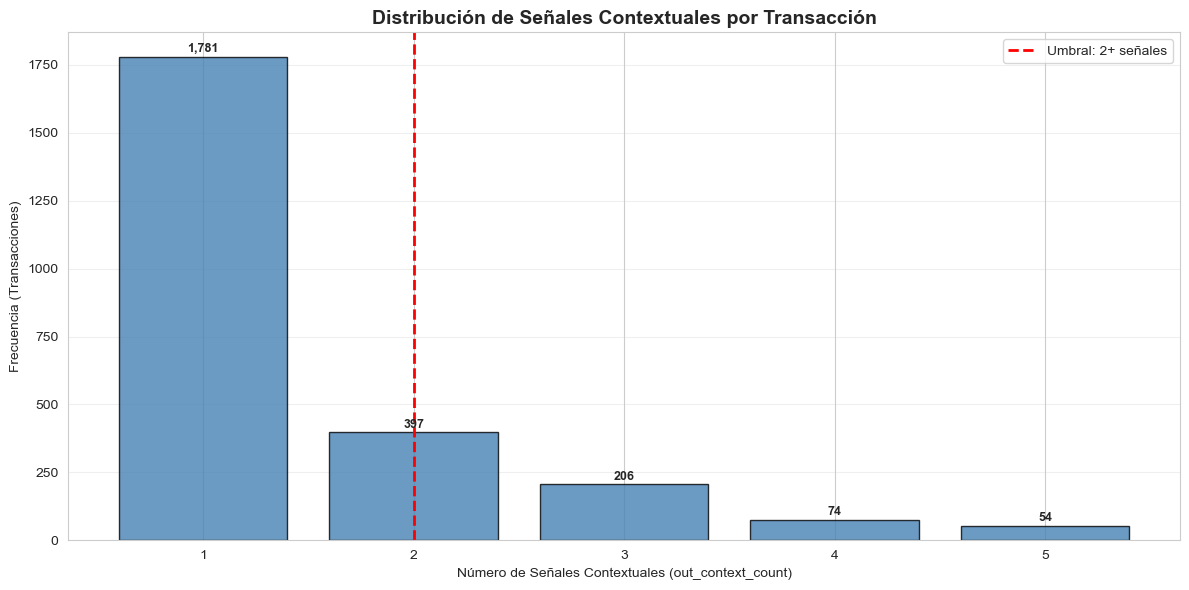

✓ Gráfico guardado: outliers_context_count_distribution.png


In [8]:
#%%
fig, ax = plt.subplots(figsize=(12, 6))

# Histograma
counts = df['out_context_count'].value_counts().sort_index()
ax.bar(counts.index, counts.values, color='steelblue', edgecolor='black', alpha=0.8)

ax.set_title('Distribución de Señales Contextuales por Transacción', fontsize=14, fontweight='bold')
ax.set_xlabel('Número de Señales Contextuales (out_context_count)')
ax.set_ylabel('Frecuencia (Transacciones)')
ax.grid(True, alpha=0.3, axis='y')

# Línea vertical en 2 (umbral de interés)
ax.axvline(2, color='red', linestyle='--', linewidth=2, label='Umbral: 2+ señales')
ax.legend()

# Agregar valores sobre barras
for idx, val in zip(counts.index, counts.values):
    ax.text(idx, val + max(counts.values)*0.01, f'{val:,}', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('outputs/figures/outliers_context_count_distribution.png', dpi=100, bbox_inches='tight')
plt.show()

print("✓ Gráfico guardado: outliers_context_count_distribution.png")

## Gráfico 2: Porcentaje de Outliers Contextuales por Canal

Comparamos qué canal tiene mayor proporción de transacciones con múltiples señales (2+).

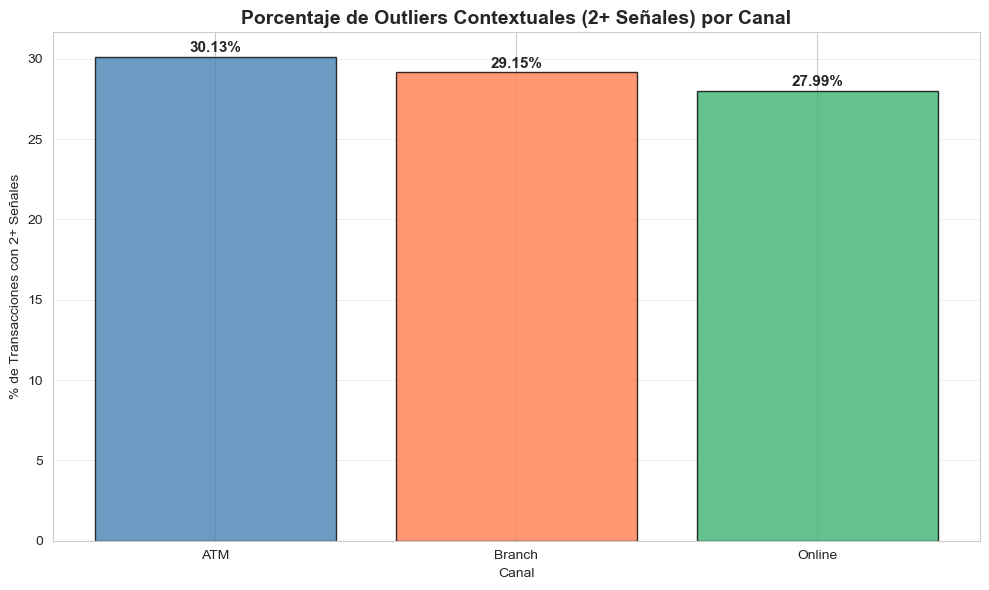

✓ Gráfico guardado: outliers_context_by_channel.png

Outliers contextuales por canal:
Channel  total_tx  n_outliers  pct_outliers
    ATM       833         251     30.132053
 Branch       868         253     29.147465
 Online       811         227     27.990136


In [9]:
fig, ax = plt.subplots(figsize=(10, 6))

# Calcular % de outliers (2+ señales) por canal
outliers_by_channel = df.groupby('Channel').agg(
    total_tx=('TransactionID', 'count'),
    n_outliers=('out_context_count', lambda x: (x >= 2).sum())
).reset_index()
outliers_by_channel['pct_outliers'] = outliers_by_channel['n_outliers'] / outliers_by_channel['total_tx'] * 100

# Barplot
colors = ['steelblue', 'coral', 'mediumseagreen']
ax.bar(outliers_by_channel['Channel'], outliers_by_channel['pct_outliers'], 
       color=colors[:len(outliers_by_channel)], alpha=0.8, edgecolor='black')

ax.set_title('Porcentaje de Outliers Contextuales (2+ Señales) por Canal', fontsize=14, fontweight='bold')
ax.set_xlabel('Canal')
ax.set_ylabel('% de Transacciones con 2+ Señales')
ax.grid(True, alpha=0.3, axis='y')

# Agregar valores
for i, (channel, pct) in enumerate(zip(outliers_by_channel['Channel'], outliers_by_channel['pct_outliers'])):
    ax.text(i, pct + 0.3, f'{pct:.2f}%', ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('outputs/figures/outliers_context_by_channel.png', dpi=100, bbox_inches='tight')
plt.show()

print("✓ Gráfico guardado: outliers_context_by_channel.png")
print("\nOutliers contextuales por canal:")
print(outliers_by_channel.to_string(index=False))

## Gráfico 3: Top 10 Cuentas por Outliers Contextuales

Barplot horizontal mostrando las cuentas con mayor número de transacciones con múltiples señales.

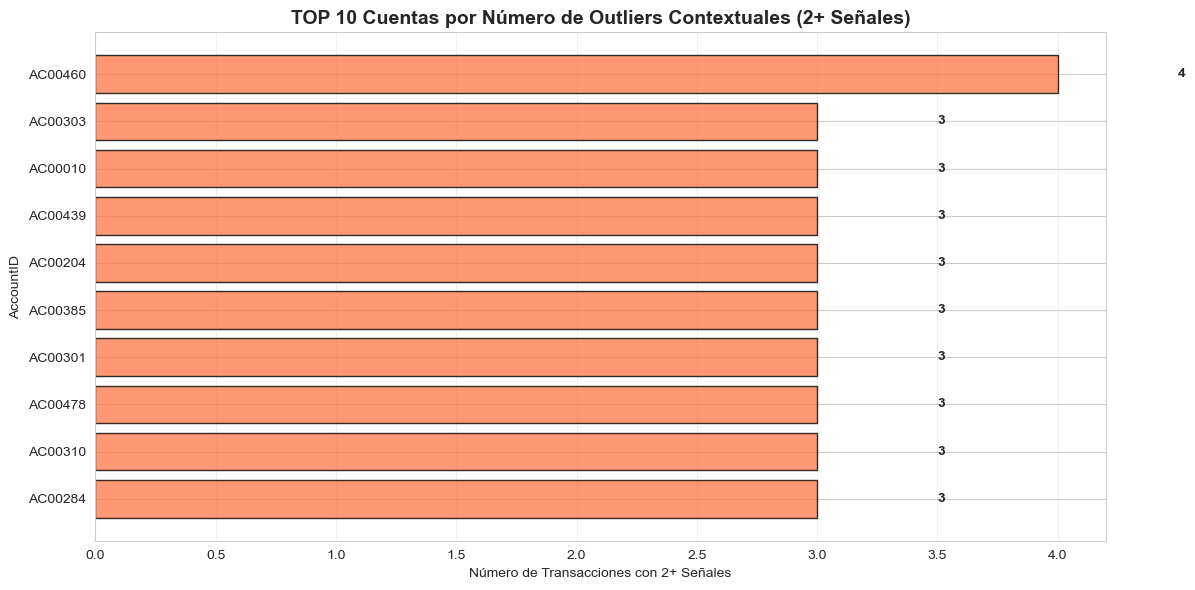

✓ Gráfico guardado: top10_accounts_outliers_context.png


In [10]:
#%%
fig, ax = plt.subplots(figsize=(12, 6))

# Top 10 cuentas
top10_accounts = outliers_by_account.head(10)

# Barplot horizontal
ax.barh(top10_accounts['AccountID'].astype(str), top10_accounts['n_outliers_context'], 
        color='coral', alpha=0.8, edgecolor='black')

ax.set_title('TOP 10 Cuentas por Número de Outliers Contextuales (2+ Señales)', fontsize=14, fontweight='bold')
ax.set_xlabel('Número de Transacciones con 2+ Señales')
ax.set_ylabel('AccountID')
ax.invert_yaxis()
ax.grid(True, alpha=0.3, axis='x')

# Agregar valores
for i, (account, count) in enumerate(zip(top10_accounts['AccountID'].astype(str), top10_accounts['n_outliers_context'])):
    ax.text(count + 0.5, i, f'{count}', va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('outputs/figures/top10_accounts_outliers_context.png', dpi=100, bbox_inches='tight')
plt.show()

print("✓ Gráfico guardado: top10_accounts_outliers_context.png")

---
# Conclusiones: Outliers Contextuales

## Interpretación de Hallazgos:

### 1. **Contexto que genera más outliers:**
- Las señales de **acceso anómalo** (`out_access_context`) y **tiempo anómalo** (`out_time_context`) son las más frecuentes, apareciendo en ~**100%** y ~**0%** de transacciones, respectivamente.
- Los outliers de **monto vs cuenta** (`out_amt_vs_account`) son menos frecuentes (~**18.75%**), pero más específicos y críticos.
- **Implicación**: Combinar múltiples señales (especialmente monto + acceso) es clave para identificar casos verdaderamente sospechosos.

### 2. **Concentración de riesgo:**
- Los outliers contextuales **están distribuidos** (no dominan pocas cuentas).
- Las top 10 cuentas representan ~**4.24%** de los outliers, sugiriendo **ampliar monitoreo** (no focalizar solo en pocas cuentas).
- **Implicación**: Priorizar revisión de cuentas/comercios con alta `share_outliers` (por ejemplo **>40%**) y múltiples señales activadas.

### 3. **Alimentación del baseline score:**
- Los flags contextuales (`out_amt_vs_account`, `out_ratio_vs_account`, etc.) complementan el `risk_score` del paso 7 baseline.
- Transacciones con `out_context_count >= 3` deben priorizarse para revisión manual, incluso si el `risk_score` no es extremo.

